In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use("ggplot")
sns.set(font_scale=1)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

df = pd.read_csv("StayEase_Cleaned_Dataset.csv")
df.head()

,hotel_type,booking_status,advance_booking_days,arrival_year,arrival_month,arrival_week,arrival_day,weekend_nights,weekday_nights,num_adults,num_children,num_infants,meal_plan,guest_country,booking_segment,booking_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room,assigned_room,modifications,deposit_type,travel_agent_id,corporate_id,waiting_days,customer_category,avg_daily_rate,parking_spaces,special_requests,reservation_status,reservation_date,total_stay_nights,booking_season,family_booking,total_guests,is_long_stay
0,Luxury Resort,1,2,2016,June,24,5,1,0,2,0.0,0,SB,Unknown,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,NaN,Not Applicable,0,Regular,109.0,0,1,Cancelled,04-06-2016,1,Summer,0,2.0,0
1,Urban Hotel,1,82,2016,September,38,15,0,3,2,0.0,0,SB,GBR,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.0,Not Applicable,0,Regular,149.4,0,1,Cancelled,12-09-2016,3,Autumn,0,2.0,0
2,Luxury Resort,0,62,2015,August,34,20,2,8,2,0.0,0,SB,ESP,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,243.0,Not Applicable,0,Regular,104.0,0,0,Checked-Out,30-08-2015,10,Summer,0,2.0,1
3,Urban Hotel,0,133,2016,May,21,17,0,3,2,0.0,0,SB,NLD,Online TA,TA/TO,0,0,0,A,B,1,No Deposit,9.0,Not Applicable,0,Regular-Party,105.3,0,0,Checked-Out,20-05-2016,3,Spring,0,2.0,0
4,Luxury Resort,1,87,2016,August,33,12,1,2,2,1.0,0,SB,BRA,Direct,Direct,0,0,0,A,A,0,No Deposit,250.0,Not Applicable,0,Regular,204.0,0,0,Cancelled,02-06-2016,3,Summer,1,3.0,0


In [2]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])
df.info()
df.describe(include="all").T

datatype_table = pd.DataFrame({
    "Column":df.columns,
    "Datatype":df.dtypes
})
datatype_table

missing = pd.DataFrame({
    "Missing Values":df.isnull().sum(),
    "Percentage":round(df.isnull().mean()*100,2)
})
missing.sort_values("Missing Values",ascending=False)    #to count number of missing values which are from travel agent id meaning these are the people booked directly from hotel

duplicates = df.duplicated().sum()
print("Duplicate Rows :",duplicates)  #

Rows : 102658
Columns : 37
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102658 entries, 0 to 102657
Data columns (total 37 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel_type                      102658 non-null  object 
 1   booking_status                  102658 non-null  int64  
 2   advance_booking_days            102658 non-null  int64  
 3   arrival_year                    102658 non-null  int64  
 4   arrival_month                   102658 non-null  object 
 5   arrival_week                    102658 non-null  int64  
 6   arrival_day                     102658 non-null  int64  
 7   weekend_nights                  102658 non-null  int64  
 8   weekday_nights                  102658 non-null  int64  
 9   num_adults                      102658 non-null  int64  
 10  num_children                    102658 non-null  float64
 11  num_infants                     102658 non-null  in

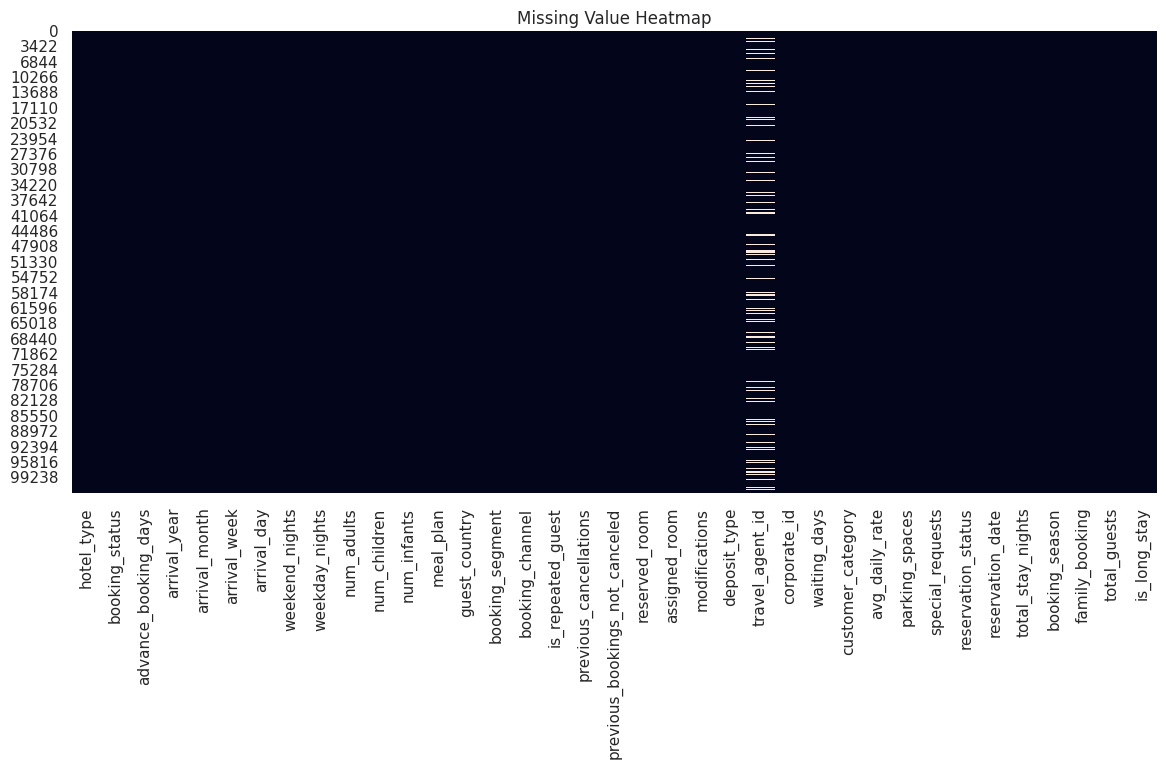

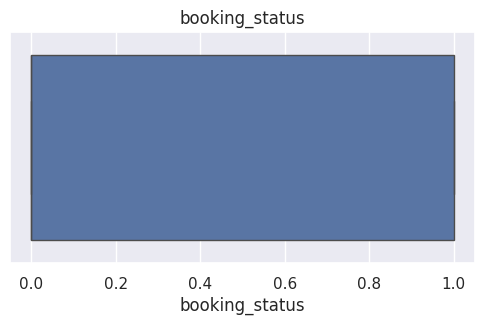

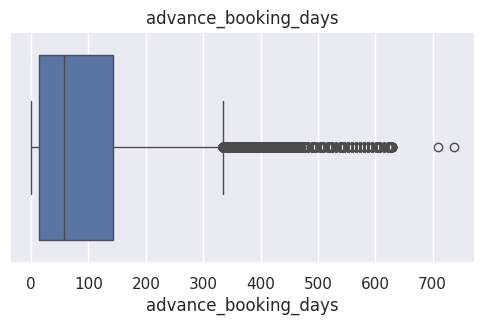

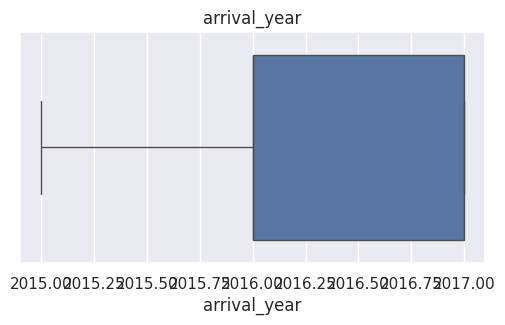

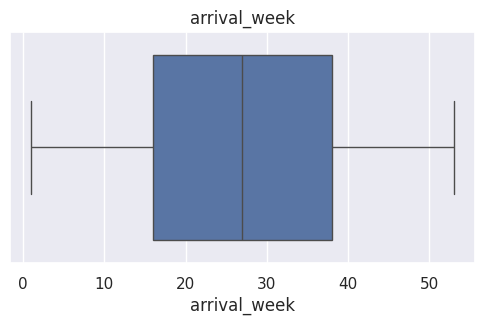

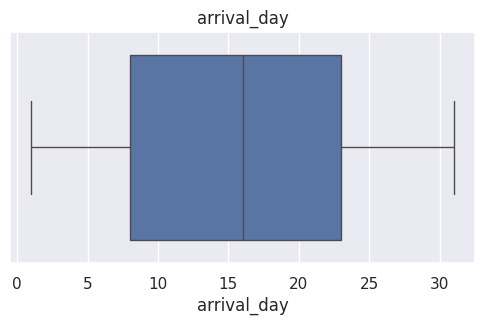

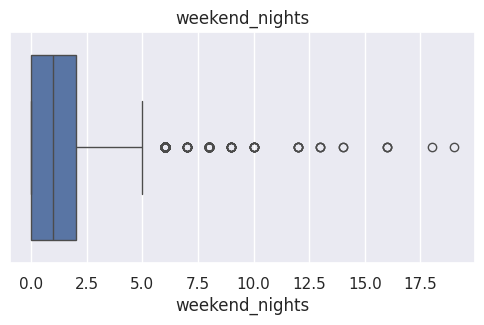

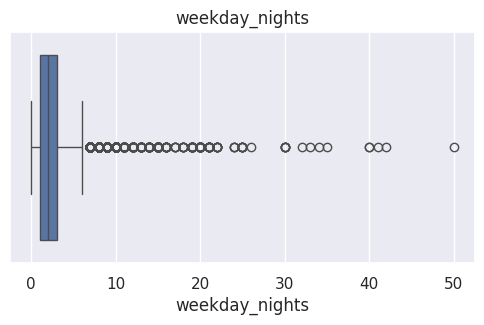

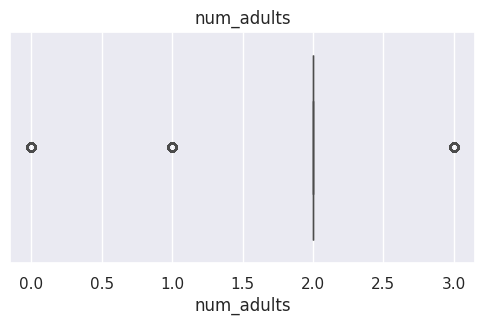

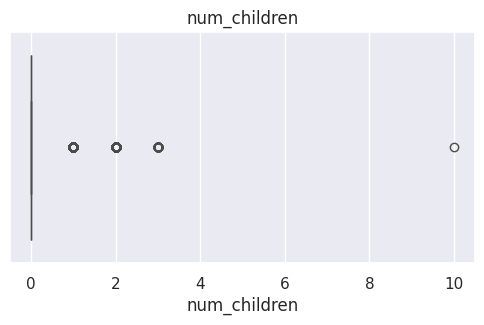

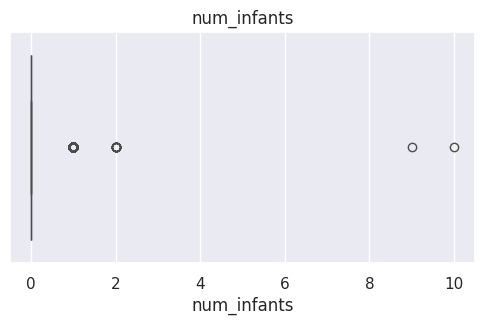

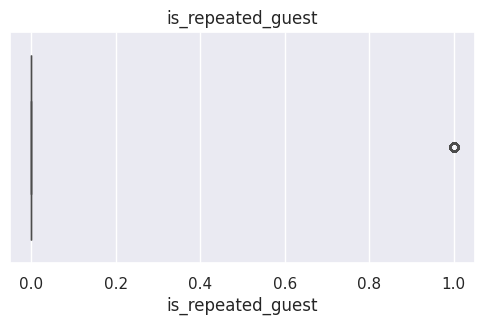

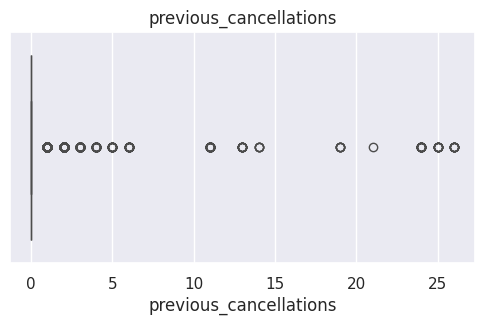

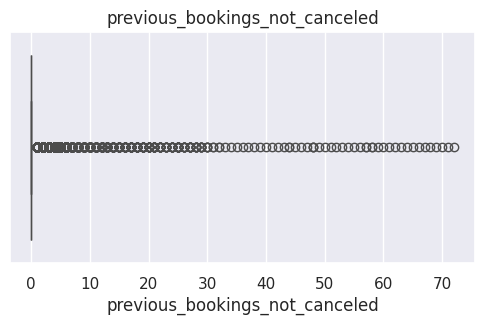

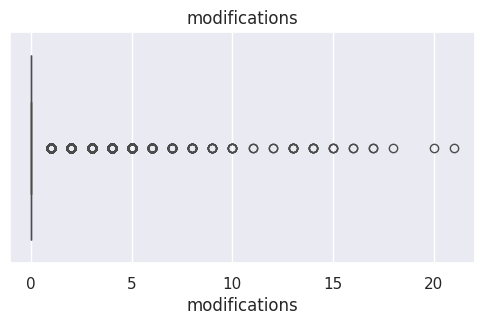

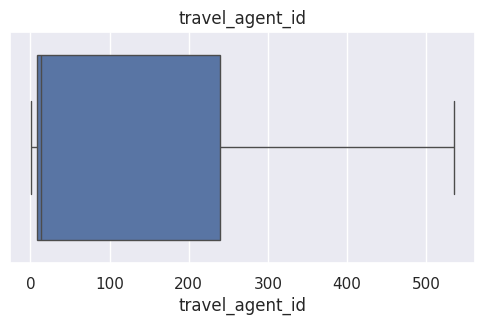

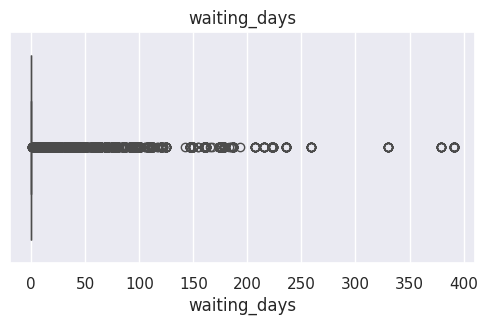

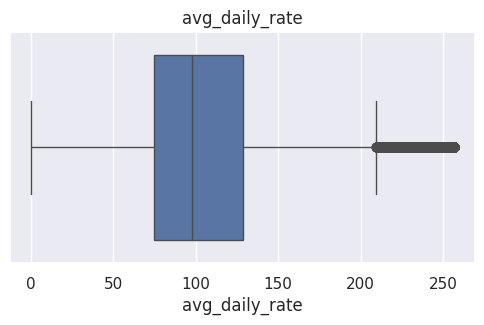

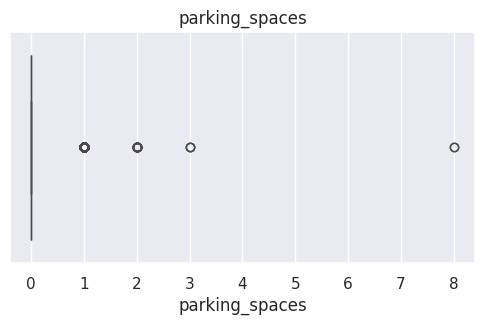

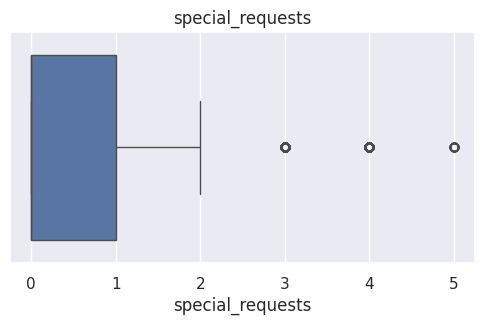

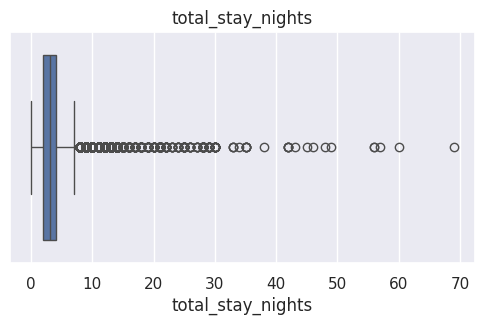

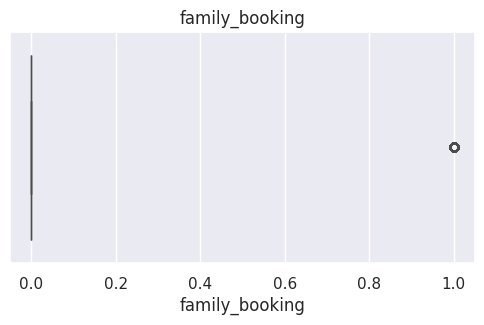

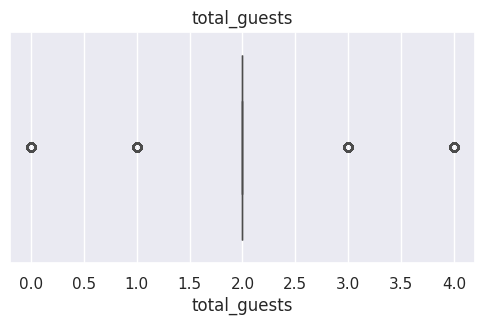

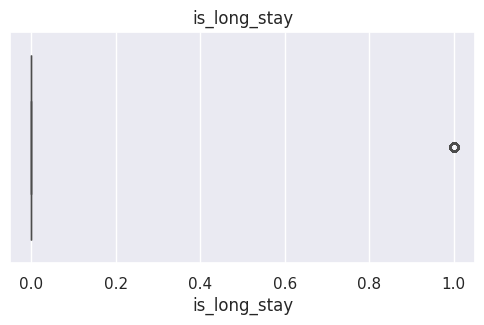

booking_status : 0
advance_booking_days : 2836
arrival_year : 0
arrival_week : 0
arrival_day : 0
weekend_nights : 230
weekday_nights : 3217
num_adults : 26168
num_children : 8353
num_infants : 913
is_repeated_guest : 3650
previous_cancellations : 3713
previous_bookings_not_canceled : 3626
modifications : 17113
travel_agent_id : 0
waiting_days : 2051
avg_daily_rate : 3836
parking_spaces : 7372
special_requests : 2817
total_stay_nights : 5045
family_booking : 9095
total_guests : 33993
is_long_stay : 13157


In [3]:
plt.figure(figsize=(14,6))
sns.heatmap(df.isnull(),cbar=False)

plt.title("Missing Value Heatmap")
plt.show()

numerical = df.select_dtypes(include=np.number).columns

for col in numerical:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

for col in numerical:
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr=q3-q1
    lower=q1-1.5*iqr
    upper=q3+1.5*iqr
    outliers=((df[col]<lower)|(df[col]>upper)).sum()
    print(col,":",outliers)

In [4]:
df = df.drop_duplicates()
df["reservation_date"] = pd.to_datetime(df["reservation_date"],format="%d-%m-%Y")
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 89398 entries, 0 to 102656
Data columns (total 37 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   hotel_type                      89398 non-null  object        
 1   booking_status                  89398 non-null  int64         
 2   advance_booking_days            89398 non-null  int64         
 3   arrival_year                    89398 non-null  int64         
 4   arrival_month                   89398 non-null  object        
 5   arrival_week                    89398 non-null  int64         
 6   arrival_day                     89398 non-null  int64         
 7   weekend_nights                  89398 non-null  int64         
 8   weekday_nights                  89398 non-null  int64         
 9   num_adults                      89398 non-null  int64         
 10  num_children                    89398 non-null  float64       
 11  num_in

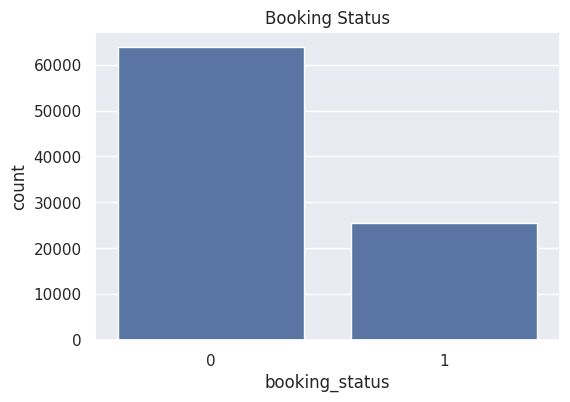

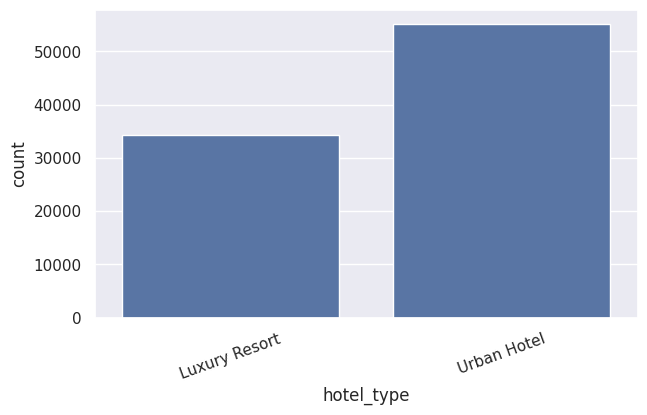

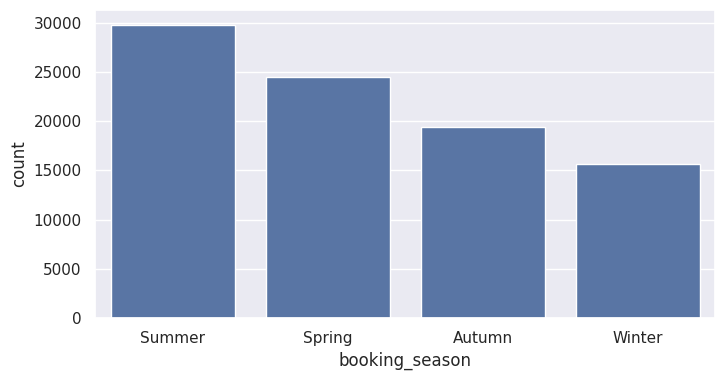

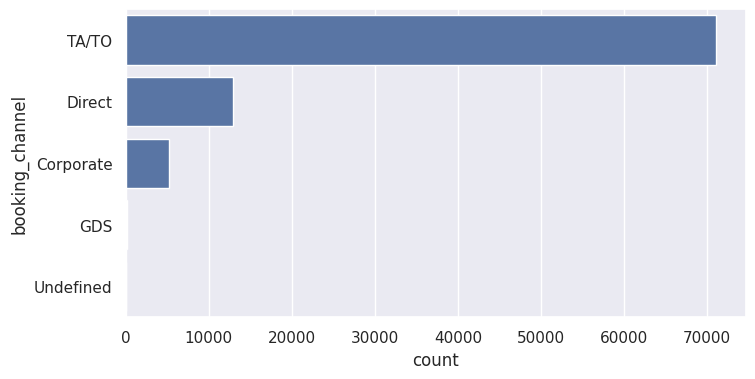

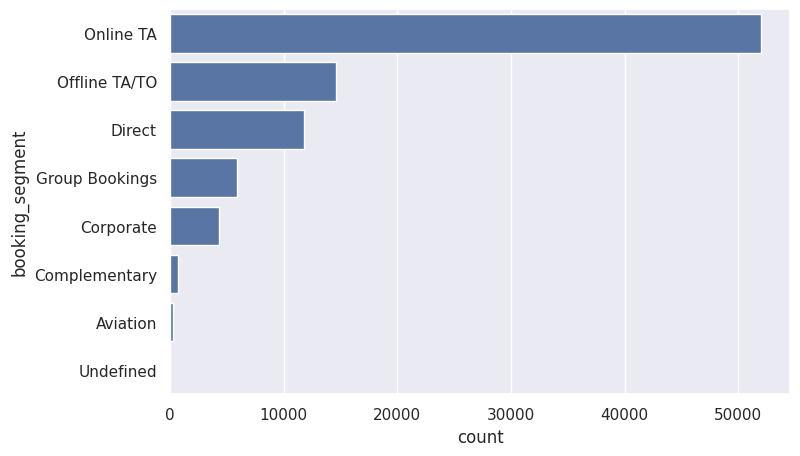

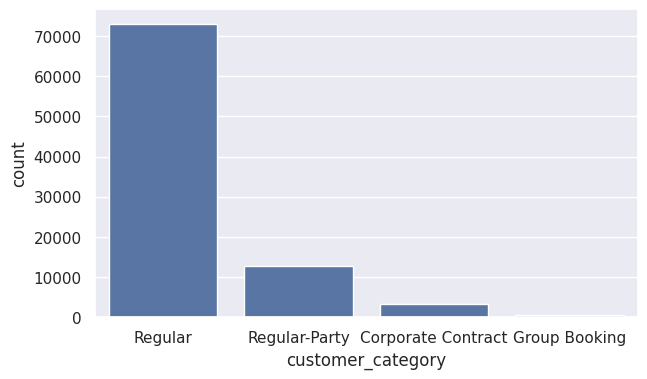

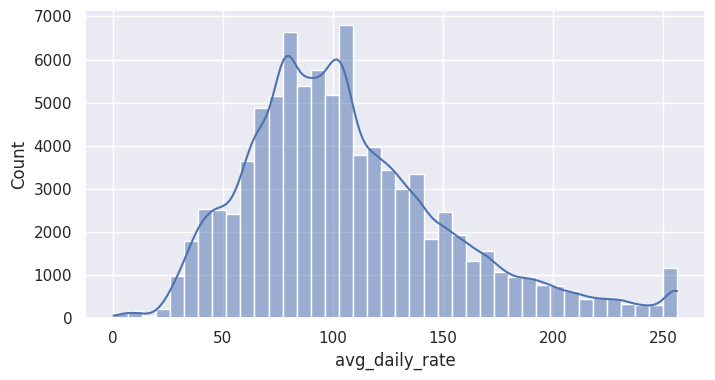

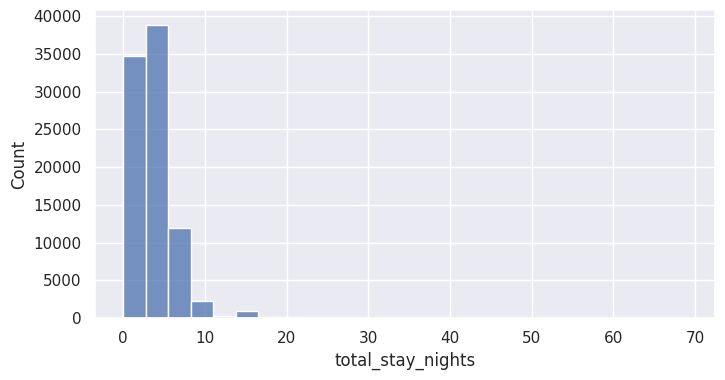

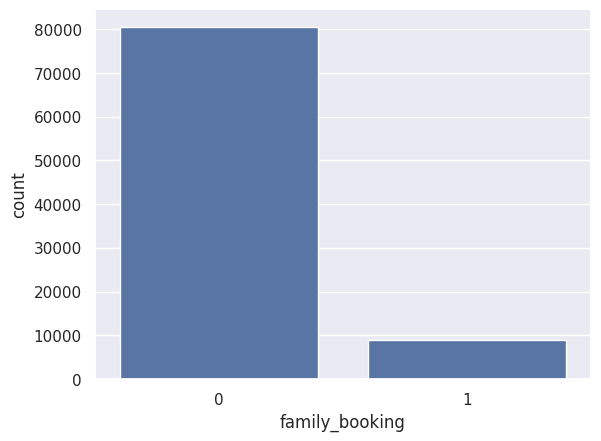

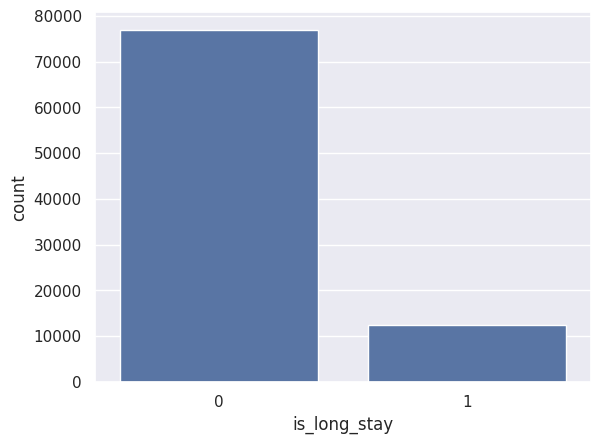

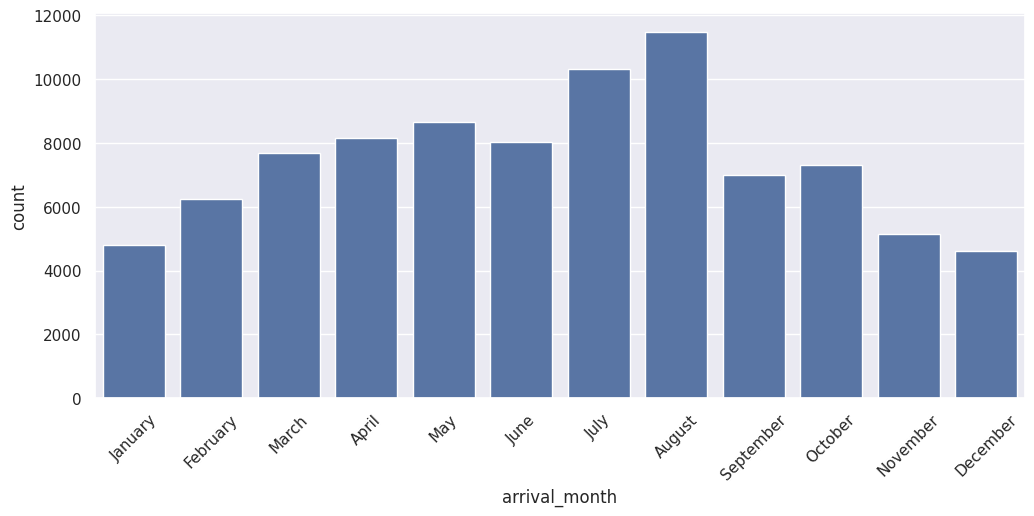

In [5]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,x="booking_status")
plt.title("Booking Status")
plt.show()

plt.figure(figsize=(7,4))

sns.countplot(data=df,x="hotel_type")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(8,4))
sns.countplot(data=df,x="booking_season",order=df["booking_season"].value_counts().index)

plt.show()

plt.figure(figsize=(8,4))
sns.countplot(data=df,y="booking_channel",order=df["booking_channel"].value_counts().index)
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(data=df,y="booking_segment",order=df["booking_segment"].value_counts().index)
plt.show()

plt.figure(figsize=(7,4))
sns.countplot(data=df,x="customer_category")
plt.show()

plt.figure(figsize=(8,4))

sns.histplot(df["avg_daily_rate"],bins=40,kde=True)
plt.show()

plt.figure(figsize=(8,4))
sns.histplot(df["total_stay_nights"],bins=25)
plt.show()

sns.countplot(data=df,x="family_booking")
plt.show()

sns.countplot(data=df,x="is_long_stay")
plt.show()

month_order=[
"January","February","March","April","May","June",
"July","August","September","October","November","December"
]

plt.figure(figsize=(12,5))
sns.countplot(data=df,x="arrival_month",order=month_order)
plt.xticks(rotation=45)
plt.show()

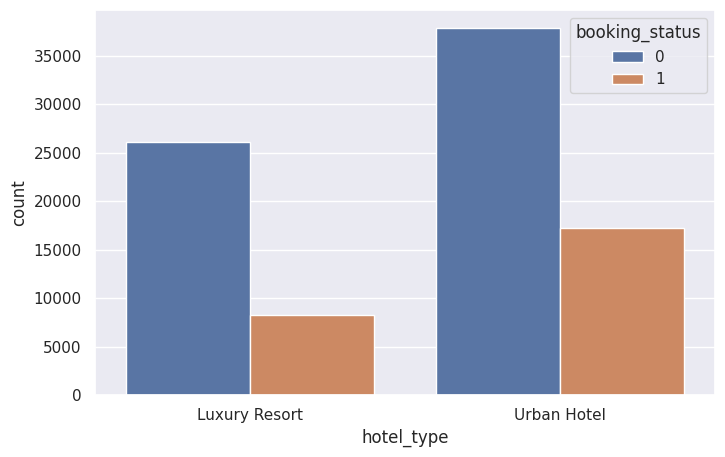

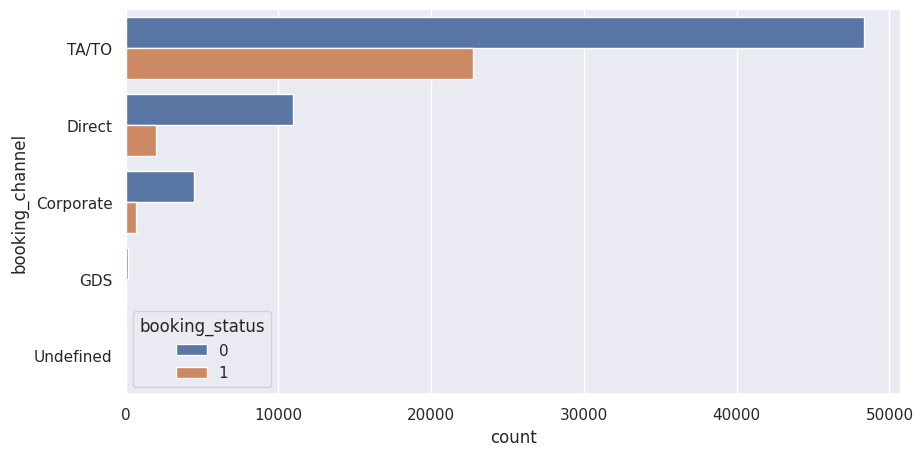

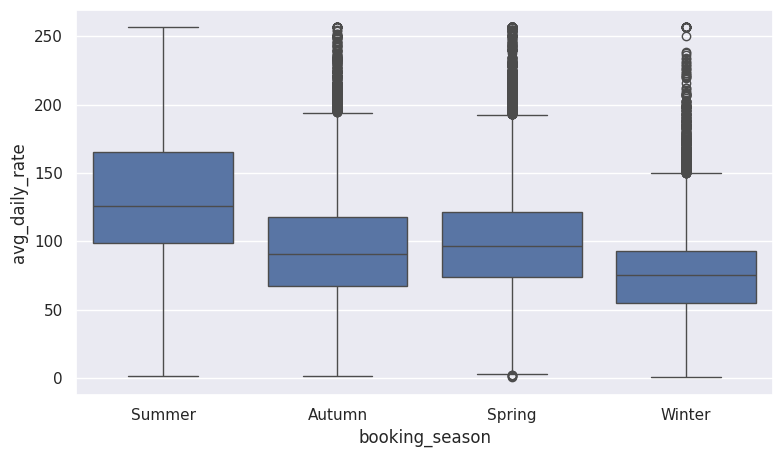

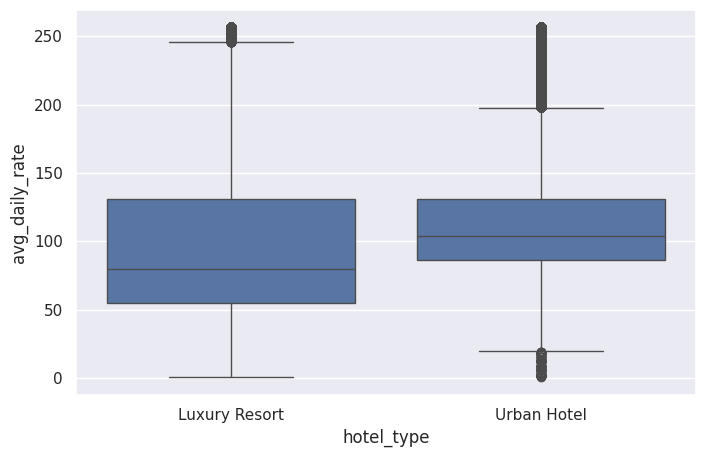

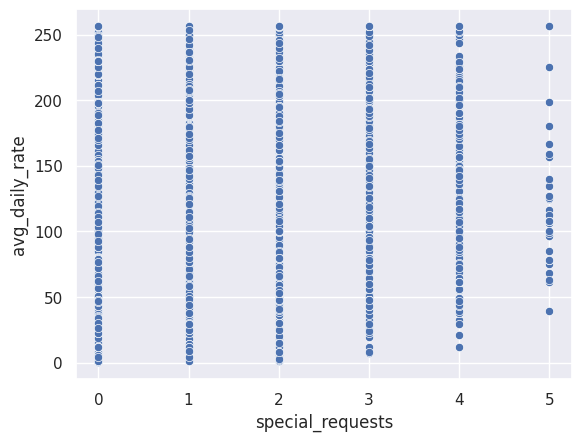

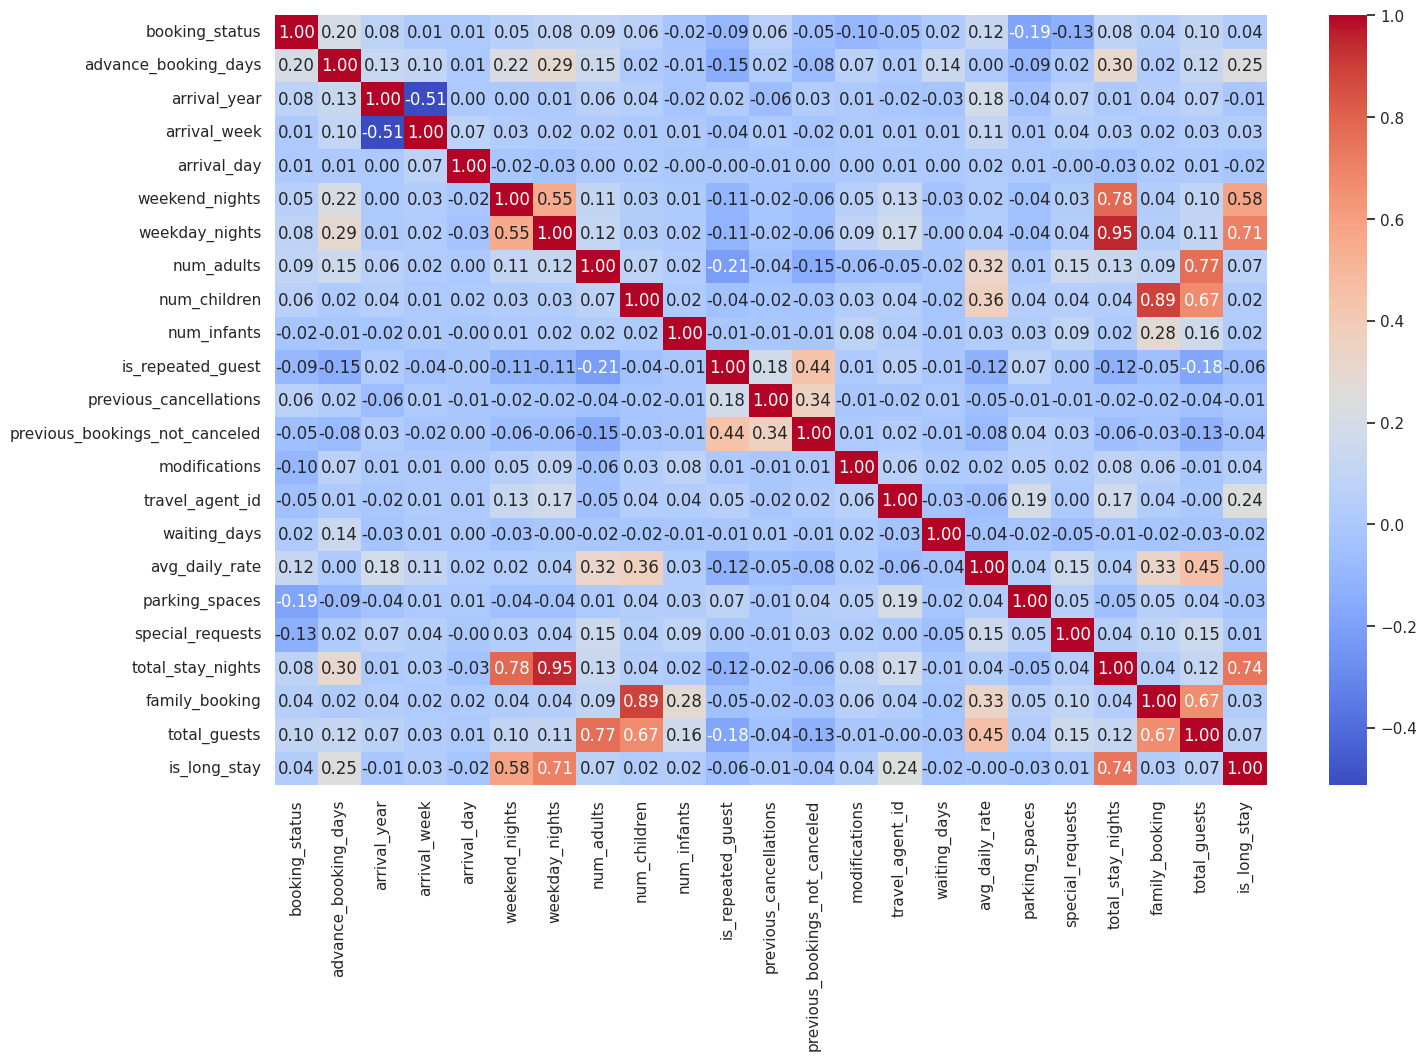

booking_status
0    71.530683
1    28.469317
Name: proportion, dtype: float64


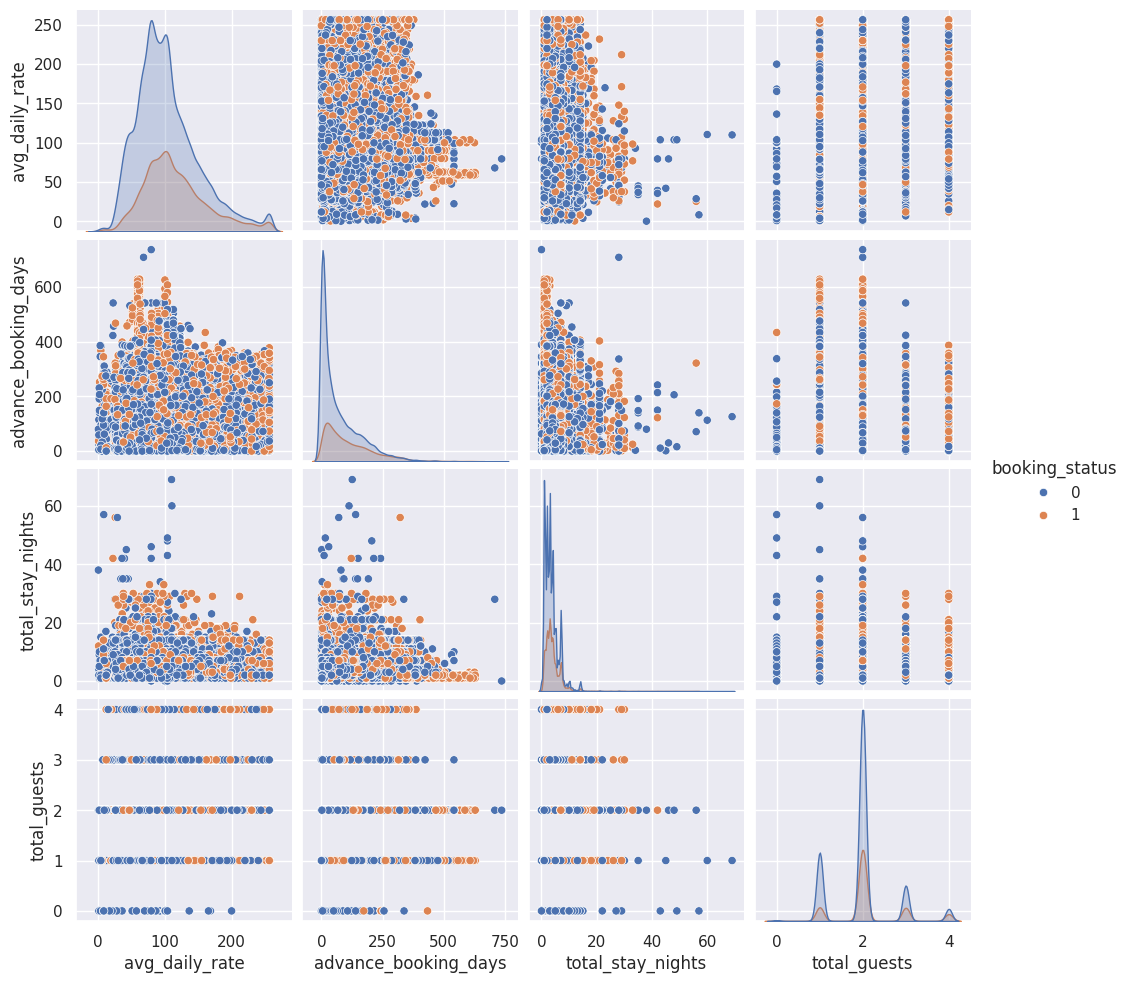

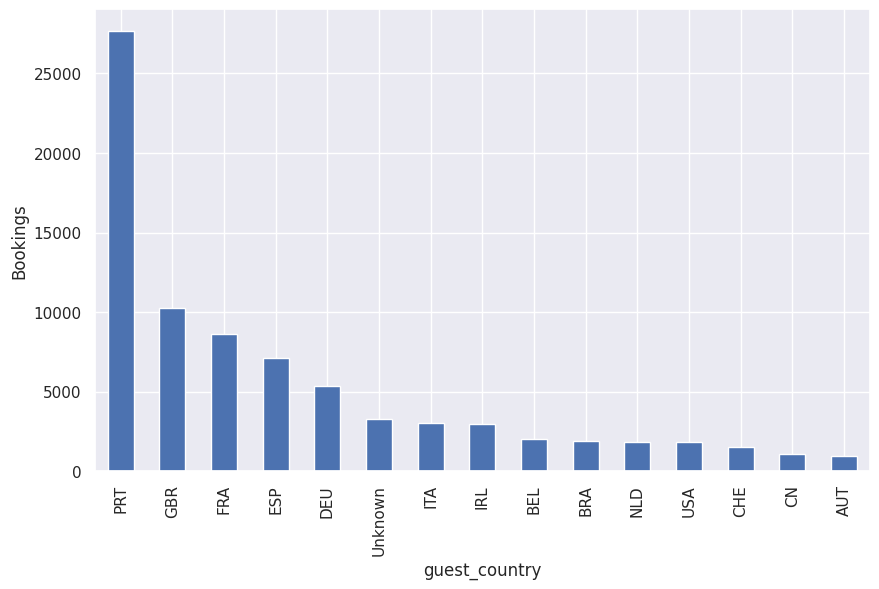

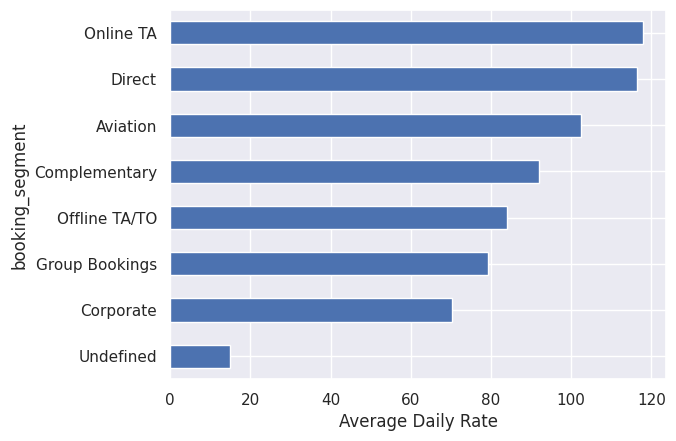

In [6]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x="hotel_type",
    hue="booking_status"
)
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    y="booking_channel",
    hue="booking_status"
)
plt.show()

plt.figure(figsize=(9,5))
sns.boxplot(
    data=df,
    x="booking_season",
    y="avg_daily_rate"
)
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,x="hotel_type",y="avg_daily_rate"
)
plt.show()

sns.scatterplot(
    data=df,
    x="special_requests",
    y="avg_daily_rate"
)
plt.show()

plt.figure(figsize=(16,10))
corr=df.corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".2f")
plt.show()

sns.pairplot(
    df[
        [
            "avg_daily_rate",
            "advance_booking_days",
            "total_stay_nights",
            "total_guests",
            "booking_status"
        ]
    ],
    hue="booking_status"
)

df.groupby("hotel_type")["avg_daily_rate"].mean().sort_values(ascending=False)
df.groupby("customer_category")["total_stay_nights"].mean()
cancel_rate = (df["booking_status"].value_counts(normalize=True)*100)
print(cancel_rate)

plt.figure(figsize=(10,6))
df["guest_country"].value_counts().head(15).plot(kind="bar")
plt.ylabel("Bookings")
plt.show()
segment = df.groupby("booking_segment")["avg_daily_rate"].mean()
segment.sort_values().plot(kind="barh")
plt.xlabel("Average Daily Rate")
plt.show()